# CH03. 선형 회귀 실습

## 실습 순서

0. 사용할 라이브러리와 패키지 불러오기

1.  (데이터) 데이터 불러오기
2.  (데이터) 학습 데이터와 테스트 데이터 구분하기
3. (모델) 모델 구성하기
4. (모델 학습) 모델 학습하기
5. (모델 성능 평가) 모델 성능 평가하기
6. (결과) 모델 동작 시각화하기

## [실습 3-1] scikit-learn 라이브러리를 이용한 선형 회귀 모델




### 0. 사용할 라이브러리와 패키지 불러오기




In [74]:
# numpy, matplotlib, pandas를 각각 np, plt, pd로 재지정해 불러온다.
# scikit-learn에서 사용할 패키지를 불러온다.
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

### 1. 데이터 불러오기




In [75]:
# 데이터(Salary_Data,csv)를 불러온다.
dataset = pd.read_csv('/content/sample_data/Salary_Data.csv')
X = dataset.iloc[:, :-1].values # iloc 함수로 데이터셋의 특징 벡터를 X에 저장
y = dataset.iloc[:, 1].values # iloc 함수로 데이터셋의 실제값을 y에 저장

### 2. 학습 데이터와 테스트 데이터 구분하기




In [76]:
# X(특징 벡터)와 y(실제값)을 학습 데이터셋과 테스트 데이터셋으로 분할한다.
# test_size를 통해 학습 데이터와 테스트 데이터의 비율을 설정한다.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 1/3)

### 3. 모델 구성하기




In [77]:
# scikit-learn 라이브러리의 선형 회귀 모델을 불러온다.
regressor = LinearRegression()

### 4. 모델 학습하기




In [78]:
# fit 함수를 통해 모델을 학습한다.
# fit 함수에는 1) 가중치 초기화 2) 손실 함수 계산 3) 가중치 업데이트가 모두 구현되어 있다.
regressor.fit(X_train, y_train) # 학습 단계에서는 학습 데이터만 사용됨
w_1 = regressor.coef_
w_0 = regressor.intercept_
print(w_1)
print(w_0)

[9473.54966895]
26390.272251247974


### 5. 모델 성능 평가하기




In [79]:
# predict 함수를 통해 선형 회귀로 얻은 예측값을 추출해 테스트 데이터로 평가한다.
y_pred = regressor.predict(X_test) # 예측 단계에서는 테스트 데이터만 사용됨
result = mean_squared_error(y_test, y_pred)
print(result)

31954370.83358


### 6. 모델 동작 시각화하기




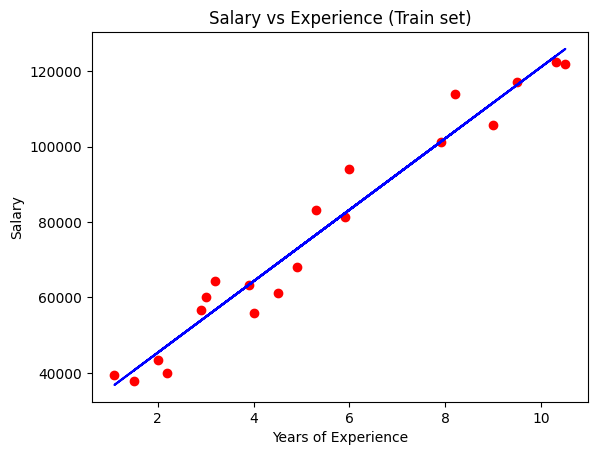

In [80]:
# 학습 데이터셋을 시각화한다(빨간색).
plt.scatter(X_train, y_train, color = 'red')
plt.plot(X_train, regressor.predict(X_train), color = 'blue')
plt.title('Salary vs Experience (Train set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()

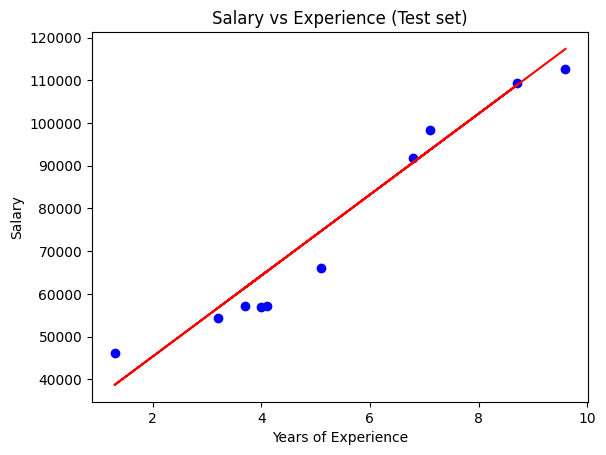

In [81]:
# 테스트 데이터셋을 시각화한다(파란색).
plt.scatter(X_test, y_test, color = 'blue')
plt.plot(X_test, regressor.predict(X_test), color = 'red')
plt.title('Salary vs Experience (Test set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()

## [실습 3-2] 함수를 직접 정의해 구현한 선형 회귀 모델




### 1. 데이터 불러오기




In [82]:
# 데이터(Salary_Data,csv)를 불러온다.
dataset = pd.read_csv('/content/sample_data/Salary_Data.csv')
X = dataset.iloc[:, :-1].values # iloc 함수로 데이터셋의 특징 벡터를 X에 저장
y = dataset.iloc[:, 1].values # iloc 함수로 데이터셋의 실제값을 y에 저장

### 2. 학습 데이터와 테스트 데이터 구분하기




In [83]:
# X(특징 벡터)와 y(실제값)을 학습 데이터셋과 테스트 데이터셋으로 분할한다.
# test_size를 통해 학습 데이터와 테스트 데이터의 비율을 설정한다.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 1/3)

### 3. 모델 구성하기




In [84]:
# 선형 회귀를 위해 필요한 함수 및 변수를 선언한다.
w_1 = 10 # 가중치 초기화
w_0 = 10
lr = 0.0025 # 학습률(일반적인 경우 0 < lr < 1)

def linear_regressor(X):
		return w_1 * X + w_0

def mean_squared_error_loss(y_pred, y):
		return (y_pred - y) * (y_pred - y)

def gradient_descent(X, y, y_pred):
		global w_1, w_0
		w_1 = w_1 - lr * 2 * X * (y_pred - y)
		w_0 = w_0 - lr * 2 * 1 * (y_pred - y)

### 4. 모델 학습하기




In [85]:
# 구현한 함수를 통해 모델을 학습한다.
# 이 함수에는 1) 가중치 초기화 2) 손실 함수 계산 3) 가중치 업데이트가 모두 구현되어 있다.
for epoch in range(100): # 원하는 만큼 반복 횟수 설정
		for X, y in zip(X_train, y_train):
				y_pred = linear_regressor(X) # 모델의 예측값 추출
				loss = mean_squared_error_loss(y_pred, y) # 손실값 계산
				gradient_descent(X, y, y_pred) # 손실값을 통한 경사하강법으로 w1, w0 업데이트
print(w_1, w_0)

[9861.18541037] [23369.29941724]


### 5. 모델 성능 평가하기




In [86]:
# linear_regressor 함수를 통해 선형 회귀로 얻은 예측값을 추출해 테스트 데이터로 평가한다.
y_pred = linear_regressor(X_test).flatten() # 예측 단계에서는 테스트 데이터만 사용됨
result = mean_squared_error(y_test, y_pred)
print(result)

43028086.63379635


### 6. 모델 동작 시각화하기



# 새 섹션

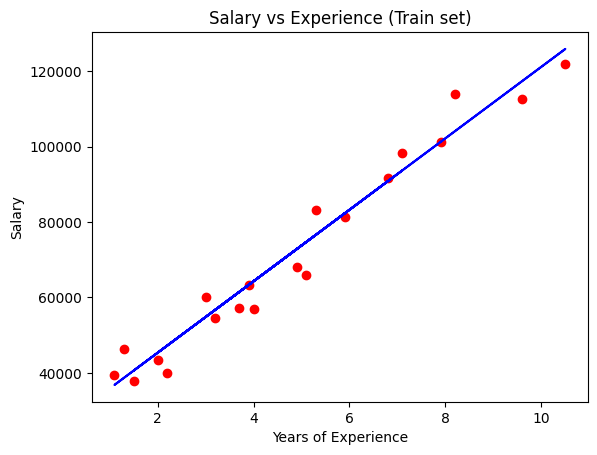

[9861.18541037] [23369.29941724]


In [87]:
# 학습 데이터셋을 시각화한다(빨간색).
plt.scatter(X_train, y_train, color = 'red')
plt.plot(X_train, regressor.predict(X_train), color = 'blue')
plt.title('Salary vs Experience (Train set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()
print(w_1, w_0)

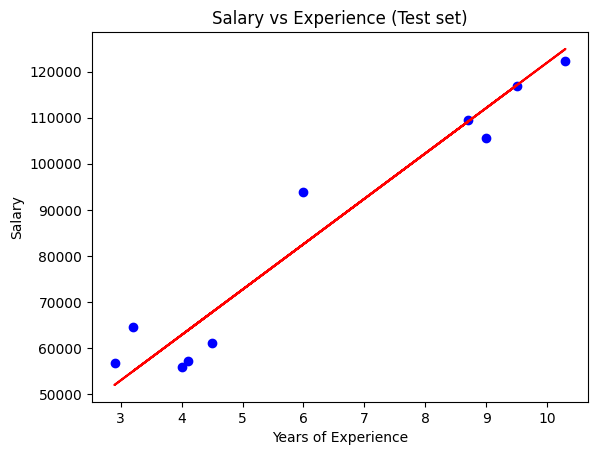

[9861.18541037] [23369.29941724]


In [88]:
# 테스트 데이터셋을 시각화한다(파란색).
plt.scatter(X_test, y_test, color = 'blue')
plt.plot(X_test, [(w_1 * x + w_0) for x in X_test], color = 'red')
plt.title('Salary vs Experience (Test set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()
print(w_1, w_0)

# 새 섹션

In [89]:
import numpy as np
import cv2

# 640x360
img = np.zeros((360, 640, 3), dtype=np.uint8)

# 도로 회색 배경
img[180:, :] = (80, 80, 80)

# 좌측 차선 (흰색 실선)
cv2.line(img, (200, 360), (290, 200), (255, 255, 255), 8)

# 우측 차선 (흰색 실선)
cv2.line(img, (440, 360), (350, 200), (255, 255, 255), 8)

# 중앙선 (노란색 점선)
for y in range(200, 360, 30):
    cv2.line(img, (320, y), (320, y+15), (0, 220, 220), 4)

cv2.imwrite("road.jpg", img)
print("가상 도로 이미지 생성 완료!")

가상 도로 이미지 생성 완료!


이미지 크기: 640 x 360


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


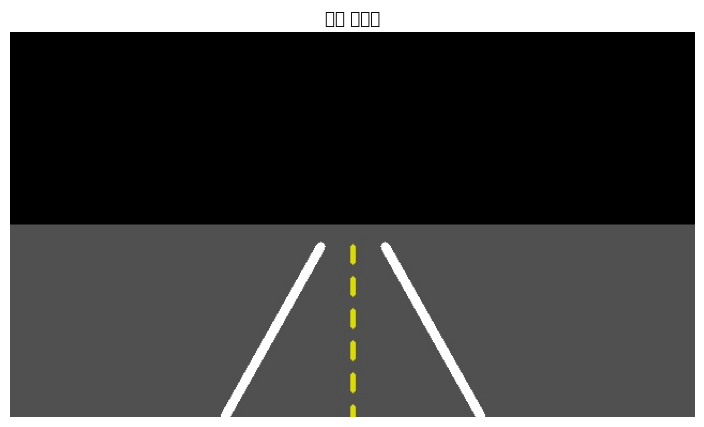

In [90]:
# 이미지 로드
image = cv2.imread('road.jpg')
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

height, width = image.shape[:2]
print(f"이미지 크기: {width} x {height}")

plt.figure(figsize=(10, 5))
plt.imshow(image_rgb)
plt.title("원본 이미지")
plt.axis('off')
plt.show()

/tmp/ipykernel_9462/3432114789.py:15: UserWarning: Glyph 44536 (\N{HANGUL SYLLABLE GEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9462/3432114789.py:15: UserWarning: Glyph 47112 (\N{HANGUL SYLLABLE RE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9462/3432114789.py:15: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9462/3432114789.py:15: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9462/3432114789.py:15: UserWarning: Glyph 52992 (\N{HANGUL SYLLABLE KE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9462/3432114789.py:15: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9462/3432114789.py:15: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(

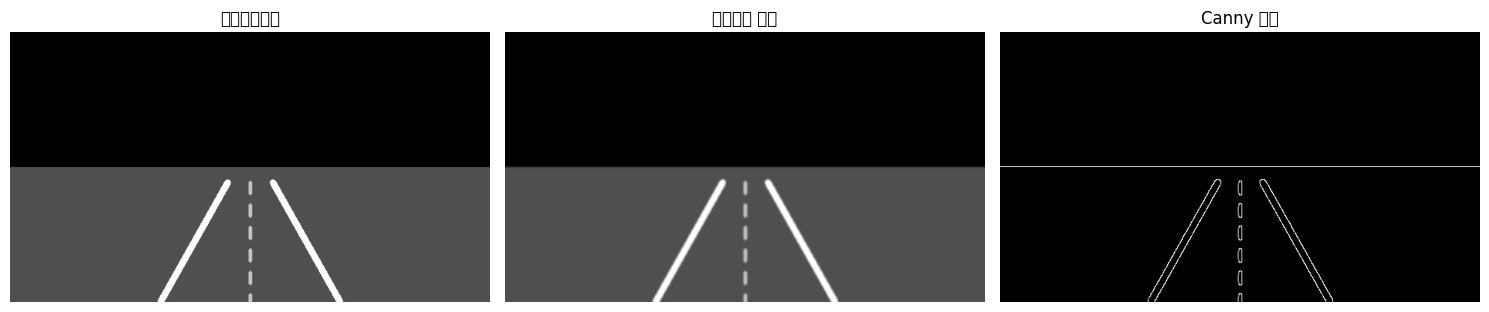

In [91]:
# 그레이스케일 변환
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# 노이즈 제거 (가우시안 블러)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# Canny 엣지 검출
edges = cv2.Canny(blurred, threshold1=50, threshold2=150)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(gray,    cmap='gray'); axes[0].set_title('그레이스케일')
axes[1].imshow(blurred, cmap='gray'); axes[1].set_title('가우시안 블러')
axes[2].imshow(edges,   cmap='gray'); axes[2].set_title('Canny 엣지')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49900 (\N{HANGUL SYLLABLE SIM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50689 (\N{HANGUL SYLLABLE YEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50669 (\N{HANGUL SYLLABLE YEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


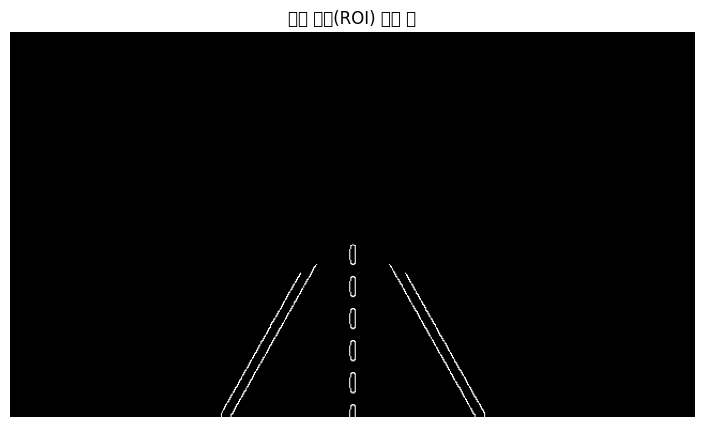

In [92]:
def region_of_interest(img):
    """도로 하단 삼각형 영역만 남기는 마스크"""
    h, w = img.shape
    # 삼각형 꼭짓점: 좌하단 - 중앙상단 - 우하단
    triangle = np.array([[
        (int(w * 0.05), h),          # 좌하단
        (int(w * 0.50), int(h * 0.55)),  # 중앙 상단 (소실점)
        (int(w * 0.95), h)           # 우하단
    ]])

    mask = np.zeros_like(img)
    cv2.fillPoly(mask, triangle, 255)       # 삼각형 안쪽을 흰색으로
    masked = cv2.bitwise_and(img, mask)     # 엣지 이미지와 AND 연산
    return masked

roi = region_of_interest(edges)

plt.figure(figsize=(10, 5))
plt.imshow(roi, cmap='gray')
plt.title("관심 영역(ROI) 적용 후")
plt.axis('off')
plt.show()

In [93]:
def fit_lane_line(points):
    """
    차선 픽셀 좌표에 선형 회귀 적용
    x = a*y + b  형태로 학습 (y를 입력, x를 출력)
    → 수직에 가까운 차선도 안정적으로 피팅 가능
    """
    if len(points) < 10:   # 픽셀이 너무 적으면 None 반환
        return None

    Y = points[:, 0].reshape(-1, 1)  # y좌표 -> 입력 X
    X = points[:, 1]                  # x좌표 -> 출력 y

    model = LinearRegression()
    model.fit(Y, X)

    return model   # 학습된 모델(기울기, 절편 포함)


def get_lane_pixels(roi_img, side='left'):
    """ROI 이미지에서 좌/우 차선 픽셀 좌표 추출"""
    h, w = roi_img.shape
    half = w // 2

    if side == 'left':
        region = roi_img[:, :half]
        ys, xs = np.where(region > 0)
    else:
        region = roi_img[:, half:]
        ys, xs = np.where(region > 0)
        xs = xs + half          # 우측이므로 x좌표 보정

    return np.column_stack((ys, xs)) if len(ys) > 0 else np.array([])


# 좌/우 차선 픽셀 추출
left_pts  = get_lane_pixels(roi, side='left')
right_pts = get_lane_pixels(roi, side='right')

# 선형 회귀 학습
left_model  = fit_lane_line(left_pts)
right_model = fit_lane_line(right_pts)

# 결과 출력
if left_model:
    print(f"[좌측 차선] 기울기(a): {left_model.coef_[0]:.4f} | 절편(b): {left_model.intercept_:.4f}")
if right_model:
    print(f"[우측 차선] 기울기(a): {right_model.coef_[0]:.4f} | 절편(b): {right_model.intercept_:.4f}")

[좌측 차선] 기울기(a): -0.4858 | 절편(b): 397.1643
[우측 차선] 기울기(a): 0.4855 | 절편(b): 241.7213


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54805 (\N{HANGUL SYLLABLE HYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54924 (\N{HANGUL SYLLABLE HOE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44480 (\N{HANGUL SYLLABLE GWI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/u

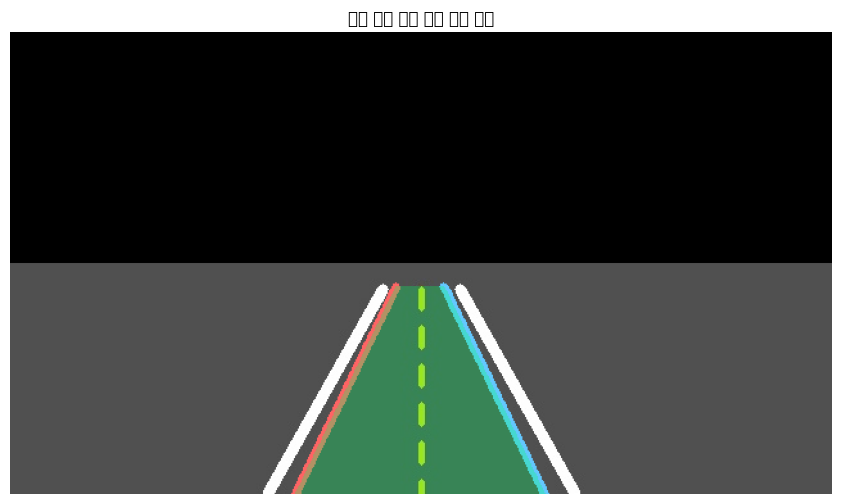

In [94]:
def draw_lane_line(img, model, color, y_start, y_end):
    """학습된 모델로 차선 직선을 이미지 위에 그리기"""
    Y_range = np.linspace(y_start, y_end, 100).reshape(-1, 1)

    X_pred = model.predict(Y_range).astype(int)
    Y_pred = Y_range.astype(int).flatten()

    pts = np.column_stack((X_pred, Y_pred))
    for i in range(len(pts) - 1):
        x1, y1 = pts[i]
        x2, y2 = pts[i+1]
        if 0 <= x1 < img.shape[1] and 0 <= x2 < img.shape[1]:
            cv2.line(img, (x1, y1), (x2, y2), color, thickness=5)


# 시각화용 이미지 복사
result = image_rgb.copy()
h = result.shape[0]
y_start = int(h * 0.55)   # 소실점(상단)
y_end   = h               # 하단

if left_model:
    draw_lane_line(result, left_model,  color=(255, 100, 100), y_start=y_start, y_end=y_end)
if right_model:
    draw_lane_line(result, right_model, color=(100, 200, 255), y_start=y_start, y_end=y_end)

# 차선 사이 영역 채우기 (주행 가능 구역 표시)
if left_model and right_model:
    Y_fill = np.linspace(y_start, y_end, 50)
    left_x  = left_model.predict(Y_fill.reshape(-1,1)).astype(int)
    right_x = right_model.predict(Y_fill.reshape(-1,1)).astype(int)

    overlay = result.copy()
    pts_left  = np.column_stack((left_x,  Y_fill.astype(int)))
    pts_right = np.column_stack((right_x, Y_fill.astype(int)))
    poly_pts  = np.vstack([pts_left, pts_right[::-1]])
    cv2.fillPoly(overlay, [poly_pts], color=(0, 255, 100))
    result = cv2.addWeighted(overlay, 0.3, result, 0.7, 0)   # 반투명 오버레이

plt.figure(figsize=(12, 6))
plt.imshow(result)
plt.title("선형 회귀 기반 차선 인식 결과")
plt.axis('off')
plt.show()

In [95]:
def check_lane_departure(left_model, right_model, image_width, image_height):
    """
    차량 중앙과 차선 중앙을 비교해 이탈 여부 판단
    - 차량 중앙: 이미지 가로 중앙 (width // 2)
    - 차선 중앙: 좌/우 차선이 하단에서 만나는 x 중간값
    """
    y_bottom = np.array([[image_height]])

    left_x_bottom  = left_model.predict(y_bottom)[0]
    right_x_bottom = right_model.predict(y_bottom)[0]

    lane_center    = (left_x_bottom + right_x_bottom) / 2
    vehicle_center = image_width / 2
    offset         = vehicle_center - lane_center

    print(f"좌측 차선 하단 x: {left_x_bottom:.1f}")
    print(f"우측 차선 하단 x: {right_x_bottom:.1f}")
    print(f"차선 중앙:       {lane_center:.1f}")
    print(f"차량 중앙:       {vehicle_center:.1f}")
    print(f"편차(offset):    {offset:+.1f} px")

    threshold = 50  # 픽셀
    if abs(offset) < threshold:
        status = "정상 주행 (차선 중앙)"
    elif offset > 0:
        status = "우측 이탈 경고!"
    else:
        status = "좌측 이탈 경고!"

    print(f"\n상태: {status}")
    return offset, status

offset, status = check_lane_departure(
    left_model, right_model,
    image_width=width, image_height=height
)

좌측 차선 하단 x: 222.3
우측 차선 하단 x: 416.5
차선 중앙:       319.4
차량 중앙:       320.0
편차(offset):    +0.6 px

상태: 정상 주행 (차선 중앙)


좌측 차선 하단 x: 222.3
우측 차선 하단 x: 416.5
차선 중앙:       319.4
차량 중앙:       320.0
편차(offset):    +0.6 px

상태: 정상 주행 (차선 중앙)


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49885 (\N{HANGUL SYLLABLE SIG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54200 (\N{HANGUL SYLLABLE PYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr

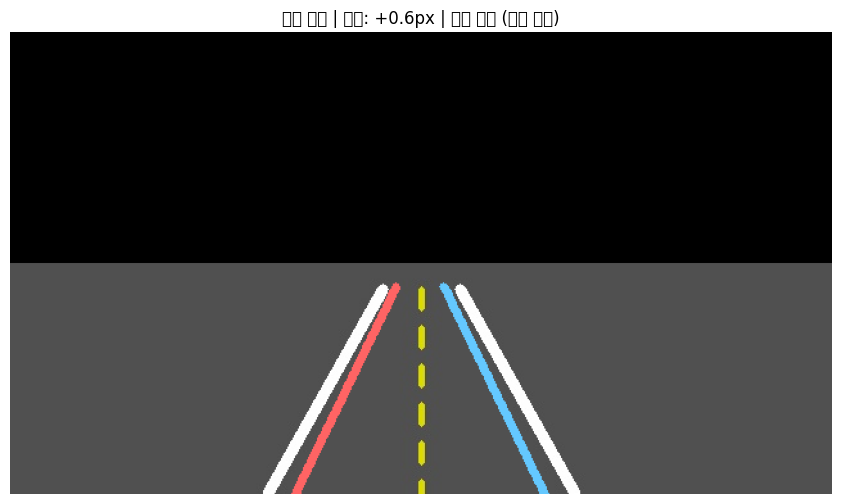

In [97]:
def lane_detection_pipeline(image_path):
    """
    LinearRegression 기반 차선 인식 전체 파이프라인
    """
    # 1. 로드
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    # 2. 전처리
    gray    = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    edges   = cv2.Canny(blurred, 50, 150)

    # 3. ROI
    roi = region_of_interest(edges)

    # 4. 픽셀 추출 + 선형 회귀
    left_pts   = get_lane_pixels(roi, 'left')
    right_pts  = get_lane_pixels(roi, 'right')
    left_model  = fit_lane_line(left_pts)
    right_model = fit_lane_line(right_pts)

    # 5. 시각화
    result = img_rgb.copy()
    y_start = int(h * 0.55)
    if left_model:
        draw_lane_line(result, left_model,  (255,100,100), y_start, h)
    if right_model:
        draw_lane_line(result, right_model, (100,200,255), y_start, h)

    # 6. 이탈 판단
    if left_model and right_model:
        offset, status = check_lane_departure(left_model, right_model, w, h)
    else:
        offset, status = 0, "차선 미검출"

    return result, offset, status

# 실행
result_img, offset, status = lane_detection_pipeline('road.jpg')
plt.figure(figsize=(12, 6))
plt.imshow(result_img)
plt.title(f"차선 인식 | 편차: {offset:+.1f}px | {status}")
plt.axis('off')
plt.show()